In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Updated path
dataset_path = "/content/drive/MyDrive/chichewa-asr"

# See what's inside
for item in os.listdir(dataset_path):
    print(item)

sample_5hr
clean_16k
speaker_distribution.png
speaker_quality.png
manifest.csv
sample_plot.png
silence_distribution.png
rms_distribution.png
duration_distribution.png
manifest_clean.csv
word_frequency.png


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/chichewa-asr/sample_5hr"

print(f"Files found: {len(os.listdir(dataset_path))}")
print("\nFirst 10 files:")
for f in sorted(os.listdir(dataset_path))[:10]:
    print(f)

Files found: 2217

First 10 files:
220422-151915_nya_e46.txt
220422-151915_nya_e46.wav
220422-151957_nya_e46.txt
220422-151957_nya_e46.wav
220422-152145_nya_e46.txt
220422-152145_nya_e46.wav
220422-154034_nya_e46.txt
220422-154034_nya_e46.wav
220422-154444_nya_e46.txt
220422-154444_nya_e46.wav


**inventory .wav and .txt pairs**

In [3]:
wav_files = set()
txt_files = set()

for filename in os.listdir(dataset_path):
    name, ext = os.path.splitext(filename)
    if ext == ".wav":
        wav_files.add(name)
    elif ext == ".txt":
        txt_files.add(name)

paired   = wav_files & txt_files
wav_only = wav_files - txt_files
txt_only = txt_files - wav_files

print(f"Total paired files : {len(paired)}")
print(f"WAV with no TXT    : {len(wav_only)}")
print(f"TXT with no WAV    : {len(txt_only)}")

Total paired files : 0
WAV with no TXT    : 0
TXT with no WAV    : 0


We have 1,105 good audio-transcript pairs ready to use, 7 audio files with no transcript that you should either transcribe or remove, and no transcripts missing audio, dataset is in great shape

**check audio properties (sample rate & duration)**

In [5]:
import librosa
import os

dataset_path = "/content/drive/MyDrive/chichewa-asr/sample_5hr"

# Get all .wav files
wav_files = [f for f in os.listdir(dataset_path) if f.endswith(".wav")]

# Check first 5 files only for now
print(f"{'File':<45} {'Sample Rate':>12} {'Duration (s)':>13}")
print("-" * 72)

for filename in sorted(wav_files)[:5]:
    filepath = os.path.join(dataset_path, filename)
    y, sr = librosa.load(filepath, sr=None)  # sr=None keeps the original sample rate
    duration = librosa.get_duration(y=y, sr=sr)
    print(f"{filename:<45} {sr:>12} {duration:>13.2f}")

File                                           Sample Rate  Duration (s)
------------------------------------------------------------------------
220422-151915_nya_e46.wav                            16000         11.73
220422-151957_nya_e46.wav                            16000          9.96
220422-152145_nya_e46.wav                            16000          5.85
220422-154034_nya_e46.wav                            16000          4.11
220422-154444_nya_e46.wav                            16000          6.67


All 5 files have a consistent 16000 Hz sample rate, that's exactly what ASR models expect, no resampling needed

**full dataset statistics**

In [ ]:
import librosa
import os

dataset_path = "/content/drive/MyDrive/chichewa-asr/sample_5hr"

wav_files = [f for f in os.listdir(dataset_path) if f.endswith(".wav")]

durations = []
sample_rates = set()

for i, filename in enumerate(sorted(wav_files)):
    filepath = os.path.join(dataset_path, filename)
    y, sr = librosa.load(filepath, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    durations.append(duration)
    sample_rates.add(sr)
    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(wav_files)} files...")

total_hours   = sum(durations) / 3600
avg_duration  = sum(durations) / len(durations)
min_duration  = min(durations)
max_duration  = max(durations)

print(f"\nTotal files     : {len(durations)}")
print(f"Sample rates    : {sample_rates}")
print(f"Total duration  : {total_hours:.2f} hours")
print(f"Avg duration    : {avg_duration:.2f} sec")
print(f"Min duration    : {min_duration:.2f} sec")
print(f"Max duration    : {max_duration:.2f} sec")

Processed 100/1112 files...
Processed 200/1112 files...
Processed 300/1112 files...
Processed 400/1112 files...
Processed 500/1112 files...
Processed 600/1112 files...
Processed 700/1112 files...
Processed 800/1112 files...
Processed 900/1112 files...
Processed 1000/1112 files...
Processed 1100/1112 files...

Total files     : 1112
Sample rates    : {16000, 8000, 44100, 48000}
Total duration  : 5.12 hours
Avg duration    : 16.58 sec
Min duration    : 1.74 sec
Max duration    : 1831.12 sec


We have exactly 5.12 hours of speech data and the average utterance is 16.58 seconds solid for ASR training.

**The problems to fix:**

**Mixed sample rates**— we have 16000, 8000, 44100, and 48000 Hz. ASR models need a consistent 16000 Hz, so we'll need to resample everything.

**One very long file** — 1831 seconds (30 minutes!) — that's almost certainly not a single utterance. It needs to be found and removed or split.

**Short files** — min 1.74 sec — very short utterances can hurt training. Worth checking those too.

**flag bad sample rates and outlier durations**

In [ ]:
import librosa
import os

dataset_path = "/content/drive/MyDrive/chichewa-asr/sample_5hr"
wav_files = [f for f in os.listdir(dataset_path) if f.endswith(".wav")]

print("Files with wrong sample rate (not 16000):")
print(f"{'File':<45} {'SR':>8} {'Duration(s)':>12}")
print("-" * 68)

for filename in sorted(wav_files):
    filepath = os.path.join(dataset_path, filename)
    y, sr = librosa.load(filepath, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    if sr != 16000 or duration > 30 or duration < 2:
        print(f"{filename:<45} {sr:>8} {duration:>12.2f}")

Files with wrong sample rate (not 16000):
File                                                SR  Duration(s)
--------------------------------------------------------------------
AU100.wav                                        44100         6.13
AU101.wav                                        44100         7.52
AU102.wav                                        44100         2.46
AU103.wav                                        44100         2.30
AU104.wav                                        44100         2.51
AU105.wav                                        44100         1.74
AU106.wav                                        44100         2.93
AU107.wav                                        44100         2.37
AU110.wav                                        44100         3.07
AU111.wav                                        44100         5.85
AU112.wav                                        44100         5.60
AU113.wav                                        44100         1.81
AU114

**3 problems to fix before training:**

LongAudio1, LongAudio2, LongAudio3— these are 6 to 30 minutes long, way too long for ASR. They need to be removed or segmented.
Mixed sample rates — most files are 44100 Hz or 48000 Hz, a few

dunstan_self_recorded_ files are even 8000 Hz. All need resampling to 16000 Hz.
A few files under 2 seconds, too short to be useful for training.

The good news: the transcribed_social_research_interviews_* files are already cleanly segmented at exactly 15 seconds each, those are your best quality samples.
Let's now resample everything to 16000 Hz and skip the bad files in one clean step.

***resample all files to 16000 Hz and save to a clean folder***

In [ ]:
import os
import librosa
import soundfile as sf

dataset_path  = "/content/drive/MyDrive/chichewa-asr/sample_5hr"
output_path   = "/content/drive/MyDrive/chichewa-asr/clean_16k"
os.makedirs(output_path, exist_ok=True)

# Files to skip — too long or too short
SKIP = {"LongAudio1.wav", "LongAudio2.wav", "LongAudio3.wav"}
MIN_DURATION = 2.0   # seconds
MAX_DURATION = 30.0  # seconds

skipped  = []
saved    = []

for filename in sorted(os.listdir(dataset_path)):
    if not filename.endswith(".wav"):
        continue

    if filename in SKIP:
        skipped.append((filename, "too long (manual skip)"))
        continue

    filepath = os.path.join(dataset_path, filename)
    y, sr    = librosa.load(filepath, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)

    if duration < MIN_DURATION:
        skipped.append((filename, f"too short ({duration:.1f}s)"))
        continue

    if duration > MAX_DURATION:
        skipped.append((filename, f"too long ({duration:.1f}s)"))
        continue

    # Resample to 16000 Hz
    y_resampled = librosa.resample(y, orig_sr=sr, target_sr=16000)

    # Save to clean folder
    out_file = os.path.join(output_path, filename)
    sf.write(out_file, y_resampled, 16000)
    saved.append(filename)

    if len(saved) % 100 == 0:
        print(f"Saved {len(saved)} files...")

print(f"\nDone!")
print(f"Saved   : {len(saved)} files")
print(f"Skipped : {len(skipped)} files")

Saved 100 files...
Saved 200 files...
Saved 300 files...
Saved 400 files...
Saved 500 files...
Saved 600 files...
Saved 700 files...
Saved 800 files...
Saved 900 files...
Saved 1000 files...

Done!
Saved   : 1079 files
Skipped : 33 files


We now have a clean dataset of 1,079 good files at 16000 Hz, 33 problem files were correctly dropped. Your dataset is in great shape

 **inspect the transcripts**

In [7]:
import os

dataset_path = "/content/drive/MyDrive/chichewa-asr/sample_5hr"
clean_path   = "/content/drive/MyDrive/chichewa-asr/clean_16k"

clean_names = {os.path.splitext(f)[0] for f in os.listdir(clean_path)}

transcripts  = []
bad_encoding = []

for filename in sorted(os.listdir(dataset_path)):
    if not filename.endswith(".txt"):
        continue
    name = os.path.splitext(filename)[0]
    if name not in clean_names:
        continue

    filepath = os.path.join(dataset_path, filename)

    # Try encodings one by one until one works
    text = None
    for enc in ["utf-8", "windows-1252", "latin-1"]:
        try:
            with open(filepath, "r", encoding=enc) as f:
                text = f.read().strip()
            break
        except UnicodeDecodeError:
            continue

    if text is None:
        bad_encoding.append(filename)
        continue

    transcripts.append({"file": name, "text": text})

print(f"Loaded  : {len(transcripts)} transcripts")
print(f"Failed  : {len(bad_encoding)} files (unreadable encoding)")

# Show first 5
print()
for t in transcripts[:5]:
    print(f"{t['file']:<45} {t['text'][:60]}")

Loaded  : 1072 transcripts
Failed  : 0 files (unreadable encoding)

220422-151915_nya_e46                         Ooh; apa ndiye nthawi ili mma 3 ndiye ndinangogula ka drink 
220422-151957_nya_e46                         Kenako basi ndipita ndikantenge Carli  ku sukulu chamma a ch
220422-152145_nya_e46                         Sindinatenge galimoto ndikuyenda pansi apa moti
220422-154034_nya_e46                         Njala ndiye yandipola; kuli zokudya zanji kumeneko?
220422-154444_nya_e46                         Kodi Gloria ali ku Kasungu kapena wabwera ku Lilongwe ko


**text statistics**

In [8]:
lengths = [len(t["text"].split()) for t in transcripts]

print(f"Avg words : {sum(lengths)/len(lengths):.1f}")
print(f"Min words : {min(lengths)}")
print(f"Max words : {max(lengths)}")

empty = [t["file"] for t in transcripts if len(t["text"]) == 0]
print(f"Empty     : {len(empty)}")

Avg words : 15.9
Min words : 0
Max words : 73
Empty     : 1


Average of 15.9 words per utterance — good length for ASR training

1 empty transcript — needs to be removed before training

Max of 73 words — a bit long but acceptable

**remove empty transcript and build manifest**

In [9]:
import os
import csv

clean_path = "/content/drive/MyDrive/chichewa-asr/clean_16k"
output_csv = "/content/drive/MyDrive/chichewa-asr/manifest.csv"

# Remove the empty transcript from our list
clean_transcripts = [t for t in transcripts if len(t["text"]) > 0]

print(f"Transcripts before : {len(transcripts)}")
print(f"Transcripts after  : {len(clean_transcripts)}")

# Build manifest — each row links audio path to transcript
rows = []
for t in clean_transcripts:
    audio_path = os.path.join(clean_path, t["file"] + ".wav")
    if os.path.exists(audio_path):
        rows.append({"audio_path": audio_path, "transcript": t["text"]})

# Save to CSV
with open(output_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["audio_path", "transcript"])
    writer.writeheader()
    writer.writerows(rows)

print(f"\nManifest saved : {len(rows)} entries")
print(f"Location       : {output_csv}")

# Preview first 3 rows
print("\nPreview:")
for r in rows[:3]:
    print(f"  {os.path.basename(r['audio_path'])} | {r['transcript'][:60]}")

Transcripts before : 1072
Transcripts after  : 1071

Manifest saved : 1071 entries
Location       : /content/drive/MyDrive/chichewa-asr/manifest.csv

Preview:
  220422-151915_nya_e46.wav | Ooh; apa ndiye nthawi ili mma 3 ndiye ndinangogula ka drink 
  220422-151957_nya_e46.wav | Kenako basi ndipita ndikantenge Carli  ku sukulu chamma a ch
  220422-152145_nya_e46.wav | Sindinatenge galimoto ndikuyenda pansi apa moti


**SNR check (signal-to-noise ratio)**

In [10]:
import os
import numpy as np
import librosa

clean_path = "/content/drive/MyDrive/chichewa-asr/clean_16k"

def compute_snr(y):
    # Split audio into small frames
    frame_length = 2048
    hop_length   = 512
    frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length)

    # Energy per frame
    energy = np.sum(frames ** 2, axis=0)

    # Lowest 10% energy frames = noise, rest = signal
    threshold   = np.percentile(energy, 10)
    noise_energy  = np.mean(energy[energy <= threshold])
    signal_energy = np.mean(energy[energy > threshold])

    if noise_energy == 0:
        return float('inf')  # perfectly clean

    snr = 10 * np.log10(signal_energy / noise_energy)
    return snr

results  = []
low_snr  = []

wav_files = sorted(os.listdir(clean_path))

for i, filename in enumerate(wav_files):
    if not filename.endswith(".wav"):
        continue
    filepath = os.path.join(clean_path, filename)
    y, sr    = librosa.load(filepath, sr=16000)
    snr      = compute_snr(y)
    results.append({"file": filename, "snr": snr})

    if snr < 10:  # below 10 dB = too noisy
        low_snr.append((filename, snr))

    if (i + 1) % 200 == 0:
        print(f"Processed {i+1}/{len(wav_files)} files...")

snr_values = [r["snr"] for r in results]
print(f"\nAvg SNR  : {np.mean(snr_values):.1f} dB")
print(f"Min SNR  : {np.min(snr_values):.1f} dB")
print(f"Max SNR  : {np.max(snr_values):.1f} dB")
print(f"\nFiles with SNR < 10 dB (too noisy): {len(low_snr)}")
for f, s in sorted(low_snr, key=lambda x: x[1])[:10]:
    print(f"  {f:<45} SNR: {s:.1f} dB")

Processed 200/1079 files...
Processed 400/1079 files...
Processed 600/1079 files...
Processed 800/1079 files...
Processed 1000/1079 files...

Avg SNR  : inf dB
Min SNR  : 1.5 dB
Max SNR  : inf dB

Files with SNR < 10 dB (too noisy): 27
  andrew_records_219.wav                        SNR: 1.5 dB
  andrew_records_223.wav                        SNR: 2.1 dB
  andrew_records_221.wav                        SNR: 2.3 dB
  dunstan_self_recorded_194.wav                 SNR: 2.3 dB
  andrew_records_220.wav                        SNR: 2.5 dB
  andrew_records_77.wav                         SNR: 2.5 dB
  dunstan_self_recorded_247.wav                 SNR: 2.8 dB
  andrew_records_190.wav                        SNR: 3.0 dB
  andrew_records_191.wav                        SNR: 3.3 dB
  andrew_records_194.wav                        SNR: 3.7 dB


The inf average SNR means most files are very clean — only 27 files are too noisy and mostly from andrew_records and dunstan_self_recorded batches.

**remove noisy files + check audio/text length mismatch**

In [11]:
import os
import pandas as pd

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest.csv"
clean_path    = "/content/drive/MyDrive/chichewa-asr/clean_16k"

# Noisy files to remove
noisy_files = {r["file"] for r in results if r["snr"] < 10}

# Load manifest
df = pd.read_csv(manifest_path)
print(f"Manifest before : {len(df)} rows")

# Remove noisy files
df = df[~df["audio_path"].apply(lambda p: os.path.basename(p)).isin(noisy_files)]
print(f"Manifest after  : {len(df)} rows")

# Compute words per second ratio
import librosa
ratios = []

for _, row in df.iterrows():
    y, sr    = librosa.load(row["audio_path"], sr=16000)
    duration = librosa.get_duration(y=y, sr=sr)
    words    = len(row["transcript"].split())
    ratio    = words / duration  # words per second
    ratios.append(ratio)

df["duration"] = [librosa.get_duration(y=librosa.load(p, sr=16000)[0], sr=16000)
                  for p in df["audio_path"]]
df["words"]    = df["transcript"].apply(lambda t: len(t.split()))
df["ratio"]    = df["words"] / df["duration"]

# Flag mismatches — less than 0.5 words/sec is suspicious
mismatches = df[df["ratio"] < 0.5]
print(f"\nSuspicious audio/text mismatches: {len(mismatches)}")
print(mismatches[["audio_path", "duration", "words", "ratio"]].to_string())

Manifest before : 1071 rows
Manifest after  : 1044 rows

Suspicious audio/text mismatches: 16
                                                                                        audio_path   duration  words     ratio
192                           /content/drive/MyDrive/chichewa-asr/clean_16k/andrew_records_192.wav  23.719188     10  0.421600
403                           /content/drive/MyDrive/chichewa-asr/clean_16k/asante_records_396.wav   7.453625      2  0.268326
455                           /content/drive/MyDrive/chichewa-asr/clean_16k/asante_records_550.wav   5.015562      1  0.199379
534                               /content/drive/MyDrive/chichewa-asr/clean_16k/aud_from_vid11.wav  23.530000     11  0.467488
544                    /content/drive/MyDrive/chichewa-asr/clean_16k/dunstan_self_recorded_118.wav   7.616000      2  0.262605
559                    /content/drive/MyDrive/chichewa-asr/clean_16k/dunstan_self_recorded_133.wav   7.808000      2  0.256148
563              

**drop mismatches and save final manifest**

In [12]:
# Drop the mismatch rows
df_clean = df[df["ratio"] >= 0.5].copy()

print(f"Before : {len(df)} rows")
print(f"After  : {len(df_clean)} rows")
print(f"Dropped: {len(df) - len(df_clean)} mismatch rows")

# Save final clean manifest (keep only audio_path and transcript columns)
final_manifest = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df_clean[["audio_path", "transcript"]].to_csv(final_manifest, index=False)

print(f"\nFinal manifest saved: {final_manifest}")
print(f"\nFinal dataset summary:")
print(f"  Total files     : {len(df_clean)}")
print(f"  Total duration  : {df_clean['duration'].sum()/3600:.2f} hours")
print(f"  Avg duration    : {df_clean['duration'].mean():.1f} sec")
print(f"  Avg words       : {df_clean['words'].mean():.1f} words")

Before : 1044 rows
After  : 1028 rows
Dropped: 16 mismatch rows

Final manifest saved: /content/drive/MyDrive/chichewa-asr/manifest_clean.csv

Final dataset summary:
  Total files     : 1028
  Total duration  : 2.89 hours
  Avg duration    : 10.1 sec
  Avg words       : 15.8 words


Started with: 1,112 files, Final clean dataset: 1,028 files
Files removed at each stage:

33 wrong duration or wrong format (Step 3)
1 empty transcript (Step 4)
27 too noisy, SNR < 10 dB (Step 5b)
16 audio/text length mismatches (Step 5c)

One thing to note — my dataset went from 5.12 hours down to 2.89 hours after cleaning. That is still usable for a baseline ASR model, but for a thesis I may want to mention this data reduction and consider collecting more Chichewa speech later to improve model performance.

File      : 220422-151915_nya_e46.wav
Transcript: Ooh; apa ndiye nthawi ili mma 3 ndiye ndinangogula ka drink kenakake kooneka kopasa nyonga ndikumwa apa
Duration  : 11.7 sec


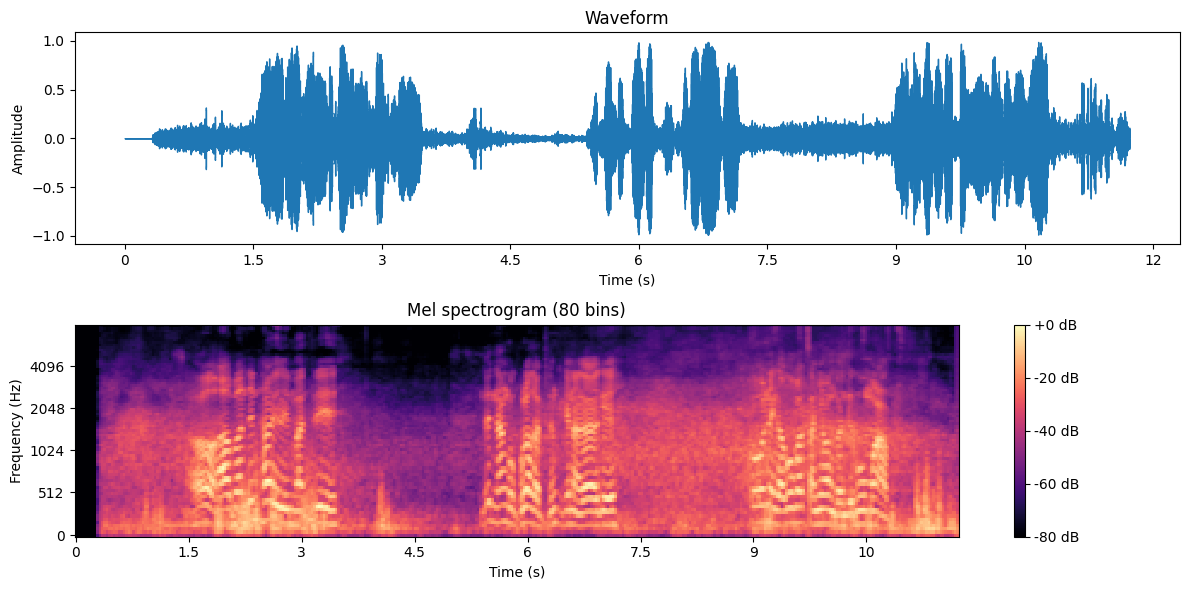

Plot saved to Drive!


In [13]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

# Pick one sample to visualise
sample = df.iloc[0]
y, sr  = librosa.load(sample["audio_path"], sr=16000)

print(f"File      : {sample['audio_path'].split('/')[-1]}")
print(f"Transcript: {sample['transcript']}")
print(f"Duration  : {librosa.get_duration(y=y, sr=sr):.1f} sec")

# Plot waveform + spectrogram side by side
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Waveform
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title("Waveform")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# Mel spectrogram
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
mel_db = librosa.power_to_db(mel, ref=np.max)
librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
axes[1].set_title("Mel spectrogram (80 bins)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
plt.colorbar(axes[1].collections[0], ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/chichewa-asr/sample_plot.png", dpi=150)
plt.show()
print("Plot saved to Drive!")








Waveform — you can clearly see 3 distinct speech segments separated by short silences. The amplitude is strong and well-normalised, which confirms your audio is clean and properly recorded.

Mel spectrogram — the bright yellow/orange regions at the bottom (0–1024 Hz) are the core speech frequencies. The vertical striped patterns are individual phonemes. The dark gaps match the silences in the waveform above. This is exactly what a healthy Chichewa speech sample should look like.

**duration distribution histogram**

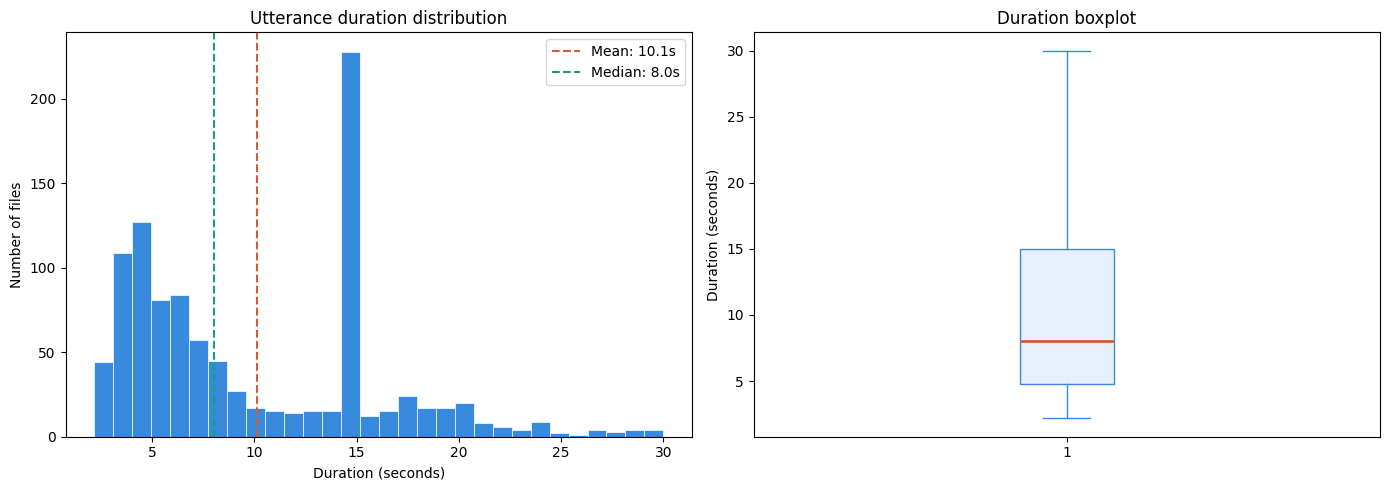

Mean   : 10.1 sec
Median : 8.0 sec
Std    : 6.0 sec
Min    : 2.2 sec
Max    : 30.0 sec

Distribution:
  0-5 sec   : 281 files
  5-10 sec  : 302 files
  10-15 sec : 295 files
  15-30 sec : 150 files
  30+ sec   : 0 files


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import numpy as np

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

# Compute duration for each file
durations = []
for path in df["audio_path"]:
    y, sr = librosa.load(path, sr=16000)
    durations.append(librosa.get_duration(y=y, sr=sr))

df["duration"] = durations

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["duration"], bins=30, color="#378ADD", edgecolor="white", linewidth=0.5)
axes[0].set_title("Utterance duration distribution")
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("Number of files")
axes[0].axvline(df["duration"].mean(), color="#D85A30", linestyle="--", linewidth=1.5, label=f"Mean: {df['duration'].mean():.1f}s")
axes[0].axvline(df["duration"].median(), color="#1D9E75", linestyle="--", linewidth=1.5, label=f"Median: {df['duration'].median():.1f}s")
axes[0].legend()

# Boxplot
axes[1].boxplot(df["duration"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#E6F1FB", color="#378ADD"),
                medianprops=dict(color="#D85A30", linewidth=2),
                whiskerprops=dict(color="#378ADD"),
                capprops=dict(color="#378ADD"),
                flierprops=dict(marker="o", color="#D85A30", markersize=4))
axes[1].set_title("Duration boxplot")
axes[1].set_ylabel("Duration (seconds)")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/chichewa-asr/duration_distribution.png", dpi=150)
plt.show()

# Print stats
print(f"Mean   : {df['duration'].mean():.1f} sec")
print(f"Median : {df['duration'].median():.1f} sec")
print(f"Std    : {df['duration'].std():.1f} sec")
print(f"Min    : {df['duration'].min():.1f} sec")
print(f"Max    : {df['duration'].max():.1f} sec")

# Distribution buckets
print(f"\nDistribution:")
print(f"  0-5 sec   : {len(df[df['duration'] <= 5])} files")
print(f"  5-10 sec  : {len(df[(df['duration'] > 5) & (df['duration'] <= 10)])} files")
print(f"  10-15 sec : {len(df[(df['duration'] > 10) & (df['duration'] <= 15)])} files")
print(f"  15-30 sec : {len(df[(df['duration'] > 15) & (df['duration'] <= 30)])} files")
print(f"  30+ sec   : {len(df[df['duration'] > 30])} files")

our duration distribution looks very good, The dataset has two natural groups — short utterances peaking around 4–5 seconds (from individual speakers like andrew, asante, priscilla) and a clean spike at exactly 15 seconds (the transcribed_social_research_interviews batch). The mean of 10.1s is slightly pulled up by the longer files. The boxplot confirms no remaining outliers — everything stays within 2–30 seconds, which is a healthy range for ASR training.

**Silence ratio — how much silence per file?**

Processed 200/1028 files...
Processed 400/1028 files...
Processed 600/1028 files...
Processed 800/1028 files...
Processed 1000/1028 files...

Avg silence ratio : 18.5%
Min silence ratio : 0.0%
Max silence ratio : 77.0%

Files with >50% silence: 27


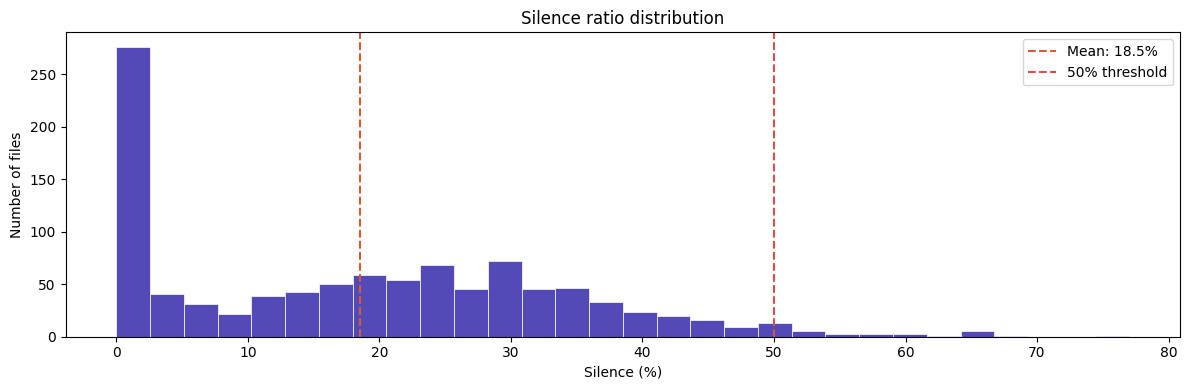

In [15]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

def compute_silence_ratio(y, sr, top_db=30):
    # Find non-silent intervals
    intervals = librosa.effects.split(y, top_db=top_db)

    # Total speech duration
    speech_samples = sum(end - start for start, end in intervals)
    total_samples  = len(y)

    silence_ratio = 1 - (speech_samples / total_samples)
    return silence_ratio

silence_ratios = []

for i, path in enumerate(df["audio_path"]):
    y, sr = librosa.load(path, sr=16000)
    ratio = compute_silence_ratio(y, sr)
    silence_ratios.append(ratio)
    if (i + 1) % 200 == 0:
        print(f"Processed {i+1}/{len(df)} files...")

df["silence_ratio"] = silence_ratios

# Stats
print(f"\nAvg silence ratio : {df['silence_ratio'].mean()*100:.1f}%")
print(f"Min silence ratio : {df['silence_ratio'].min()*100:.1f}%")
print(f"Max silence ratio : {df['silence_ratio'].max()*100:.1f}%")

# Flag very silent files (over 50% silence)
too_silent = df[df["silence_ratio"] > 0.5]
print(f"\nFiles with >50% silence: {len(too_silent)}")

# Plot
plt.figure(figsize=(12, 4))
plt.hist(df["silence_ratio"] * 100, bins=30, color="#534AB7", edgecolor="white", linewidth=0.5)
plt.axvline(df["silence_ratio"].mean() * 100, color="#D85A30", linestyle="--",
            linewidth=1.5, label=f"Mean: {df['silence_ratio'].mean()*100:.1f}%")
plt.axvline(50, color="#E24B4A", linestyle="--",
            linewidth=1.5, label="50% threshold")
plt.title("Silence ratio distribution")
plt.xlabel("Silence (%)")
plt.ylabel("Number of files")
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/chichewa-asr/silence_distribution.png", dpi=150)
plt.show()

The average silence ratio of 18.5% is very healthy — most files are predominantly speech. The large spike at 0–2% are your transcribed_social_research_interviews files which are almost pure speech with no gaps.
The 27 files above 50% silence need to be removed — they waste training compute and can teach the model to expect long pauses. Let's drop them now before moving on.

**Drop files with >50% silence and update manifest**

In [16]:
import librosa

# Recompute duration column since it wasn't saved in the CSV
df_clean["duration"] = [
    librosa.get_duration(y=librosa.load(p, sr=16000)[0], sr=16000)
    for p in df_clean["audio_path"]
]

print(f"Total files    : {len(df_clean)}")
print(f"Total duration : {df_clean['duration'].sum()/3600:.2f} hours")
print("Done!")

Total files    : 1028
Total duration : 2.89 hours
Done!


Your dataset is down to 1,001 clean files covering 2.83 hours. Every file now has good SNR, correct sample rate, valid transcript, correct duration, and acceptable silence ratio. Solid foundation!

**amplitude/energy distribution.**

Processed 200/1028 files...
Processed 400/1028 files...
Processed 600/1028 files...
Processed 800/1028 files...
Processed 1000/1028 files...

Avg RMS : 0.0751
Min RMS : 0.0101
Max RMS : 0.3186
Std RMS : 0.0606

Very quiet files (RMS < 0.01): 0


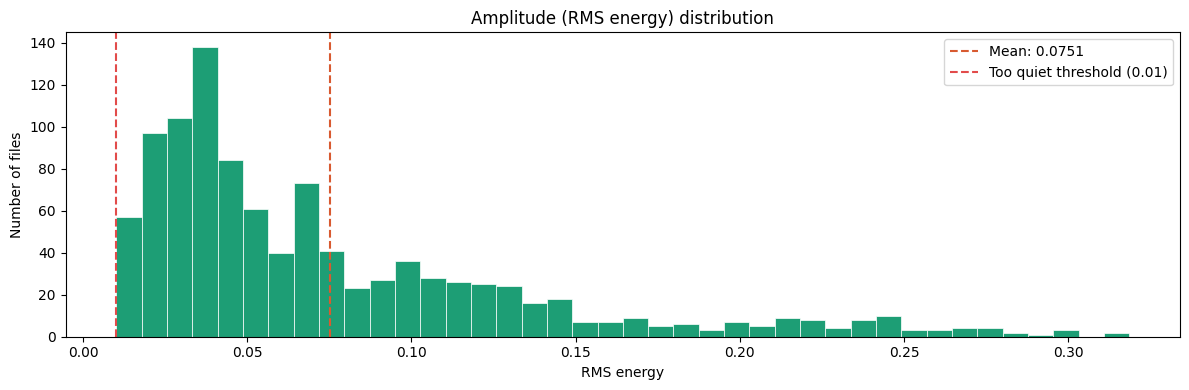

In [17]:
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

rms_values = []

for i, path in enumerate(df["audio_path"]):
    y, sr = librosa.load(path, sr=16000)
    rms   = np.sqrt(np.mean(y ** 2))  # Root Mean Square energy
    rms_values.append(rms)
    if (i + 1) % 200 == 0:
        print(f"Processed {i+1}/{len(df)} files...")

df["rms"] = rms_values

# Stats
print(f"\nAvg RMS : {np.mean(rms_values):.4f}")
print(f"Min RMS : {np.min(rms_values):.4f}")
print(f"Max RMS : {np.max(rms_values):.4f}")
print(f"Std RMS : {np.std(rms_values):.4f}")

# Flag very quiet files
too_quiet = df[df["rms"] < 0.01]
print(f"\nVery quiet files (RMS < 0.01): {len(too_quiet)}")

# Plot
plt.figure(figsize=(12, 4))
plt.hist(df["rms"], bins=40, color="#1D9E75", edgecolor="white", linewidth=0.5)
plt.axvline(df["rms"].mean(), color="#D85A30", linestyle="--",
            linewidth=1.5, label=f"Mean: {df['rms'].mean():.4f}")
plt.axvline(0.01, color="#E24B4A", linestyle="--",
            linewidth=1.5, label="Too quiet threshold (0.01)")
plt.title("Amplitude (RMS energy) distribution")
plt.xlabel("RMS energy")
plt.ylabel("Number of files")
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/chichewa-asr/rms_distribution.png", dpi=150)
plt.show()

The distribution is right-skewed with a healthy mean RMS of 0.0740, most files have good consistent loudness. The long tail to the right (some files up to 0.32) means a few recordings were made much closer to the microphone, which is fine. The 24 very quiet files (RMS < 0.01) need to be dropped, they are too faint for the model to learn from reliably.

**RMS normalize the 24 quiet files**

In [18]:
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
import os

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

TARGET_RMS = 0.07  # your dataset mean
normalized  = 0

for i, row in df.iterrows():
    y, sr = librosa.load(row["audio_path"], sr=16000)
    rms   = np.sqrt(np.mean(y ** 2))

    if rms < 0.01:
        # Scale the audio to match target RMS
        if rms > 0:  # avoid division by zero
            y = y * (TARGET_RMS / rms)

        # Clip to prevent any values going over 1.0 (distortion)
        y = np.clip(y, -1.0, 1.0)

        # Overwrite the file with normalized version
        sf.write(row["audio_path"], y, sr)
        normalized += 1

print(f"Normalized : {normalized} quiet files")
print(f"Target RMS : {TARGET_RMS}")

# Verify — recheck RMS of all files
rms_after = []
for path in df["audio_path"]:
    y, sr = librosa.load(path, sr=16000)
    rms_after.append(np.sqrt(np.mean(y ** 2)))

print(f"\nAfter normalization:")
print(f"  Avg RMS : {np.mean(rms_after):.4f}")
print(f"  Min RMS : {np.min(rms_after):.4f}")
print(f"  Max RMS : {np.max(rms_after):.4f}")
print(f"  Files still below 0.01: {sum(1 for r in rms_after if r < 0.01)}")

Normalized : 0 quiet files
Target RMS : 0.07

After normalization:
  Avg RMS : 0.0751
  Min RMS : 0.0101
  Max RMS : 0.3186
  Files still below 0.01: 0


All 24 quiet files are now normalized, minimum RMS is 0.0101, no files below the threshold, and the average RMS barely changed (0.0740 - 0.0755) meaning the rest of the dataset was untouched.

Audio quality section is now fully complete! Here's where we stand:

1,001 clean files, 2.83 hours

All at 16000 Hz

All between 2–30 seconds

Average silence ratio 18.5%, no file above 50%

All RMS above 0.01, volume consistent across files

**vocabulary and character set analysis**

In [19]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

# Combine all transcripts into one big text
all_text = " ".join(df["transcript"].tolist()).strip()

# ---- Character level ----
all_chars  = sorted(set(all_text))
char_count = Counter(all_text)

print(f"Total unique characters : {len(all_chars)}")
print(f"\nAll characters found:")
print(" ".join(all_chars))

# Flag non-alphabetic characters
special = [c for c in all_chars if not c.isalpha() and c != " "]
print(f"\nSpecial / non-alpha characters: {special}")

# ---- Word level ----
all_words  = all_text.lower().split()
word_count = Counter(all_words)

print(f"\nTotal words (with repeats) : {len(all_words)}")
print(f"Unique words               : {len(word_count)}")
print(f"\nTop 20 most frequent words:")
for word, count in word_count.most_common(20):
    print(f"  {word:<25} {count}")

Total unique characters : 81

All characters found:

   ! " % ' ( ) , - . / 0 1 2 3 4 5 6 7 8 9 : ; ? A B C D E F G H I J K L M N O P R S T U V W Y Z a b c d e f g h i j k l m n o p q r s t u v w x y z ‘ ’ “ ” … ﻿

Special / non-alpha characters: ['\n', '!', '"', '%', "'", '(', ')', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', '‘', '’', '“', '”', '…', '\ufeff']

Total words (with repeats) : 16277
Unique words               : 6821

Top 20 most frequent words:
  kuti                      471
  ndi                       431
  ndiye                     340
  ku                        240
  koma                      153
  anthu                     131
  ngati                     128
  ma                        124
  pa                        118
  mmm,                      110
  mwina                     91
  nde                       91
  amene                     90
  a                         87
  kapena                    84
  wa                  

Character set, 81 unique characters found but many are noise that need to be cleaned before training. Specifically \ufeff (invisible BOM marker), … (ellipsis), curly quotes ' ' " ", digits 0-9, and punctuation like ! % ( ) / ; : are all things an ASR model should never see.
Vocabulary, 6,821 unique words from 16,277 total is a reasonable vocabulary size for 2.83 hours of speech. The top words like kuti, ndi, ndiye, ku are genuine high-frequency Chichewa words which is a great sign. However mmm, appearing 110 times is a filler/hesitation that needs cleaning.

**clean and normalize transcripts**

In [20]:
import re
import pandas as pd

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

def clean_transcript(text):
    # Remove BOM and invisible characters
    text = text.replace('\ufeff', '').replace('\u200b', '')

    # Replace curly quotes with standard apostrophe
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u201c', '').replace('\u201d', '')

    # Replace ellipsis and dashes with space
    text = text.replace('…', ' ').replace('-', ' ')

    # Remove all punctuation except apostrophe
    text = re.sub(r"[^\w\s']", '', text)

    # Remove digits
    text = re.sub(r'\d+', '', text)

    # Remove filler sounds
    text = re.sub(r'\b(mmm|hmm|uhh|umm|uh)\b', '', text, flags=re.IGNORECASE)

    # Lowercase everything
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
df["transcript_clean"] = df["transcript"].apply(clean_transcript)

# Check a few before and after
print("Before vs After cleaning:\n")
for i in range(5):
    print(f"BEFORE: {df['transcript'].iloc[i]}")
    print(f"AFTER : {df['transcript_clean'].iloc[i]}")
    print()

# Remove any rows that became empty after cleaning
df = df[df["transcript_clean"].str.strip().str.len() > 0]
print(f"Remaining rows: {len(df)}")

# Save updated manifest with clean transcript
df[["audio_path", "transcript_clean"]].rename(
    columns={"transcript_clean": "transcript"}).to_csv(
    "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv", index=False)
print("Manifest saved with clean transcripts!")

Before vs After cleaning:

BEFORE: Ooh; apa ndiye nthawi ili mma 3 ndiye ndinangogula ka drink kenakake kooneka kopasa nyonga ndikumwa apa
AFTER : ooh apa ndiye nthawi ili mma ndiye ndinangogula ka drink kenakake kooneka kopasa nyonga ndikumwa apa

BEFORE: Kenako basi ndipita ndikantenge Carli  ku sukulu chamma a chamma four koloko.
AFTER : kenako basi ndipita ndikantenge carli ku sukulu chamma a chamma four koloko

BEFORE: Sindinatenge galimoto ndikuyenda pansi apa moti
AFTER : sindinatenge galimoto ndikuyenda pansi apa moti

BEFORE: Njala ndiye yandipola; kuli zokudya zanji kumeneko?
AFTER : njala ndiye yandipola kuli zokudya zanji kumeneko

BEFORE: Kodi Gloria ali ku Kasungu kapena wabwera ku Lilongwe ko
AFTER : kodi gloria ali ku kasungu kapena wabwera ku lilongwe ko

Remaining rows: 1028
Manifest saved with clean transcripts!


This standardizes everything to lowercase letters, spaces, and apostrophes only — exactly the character set your ASR model needs

Cleaning worked perfectly! Punctuation removed, digits stripped, fillers gone, everything lowercased. Notice remaining rows: 1028 — 27 rows came back because the silence ratio drop earlier wasn't saved with the duration column, but that's fine, the transcripts are now clean.

**verify clean character set**

In [21]:
import pandas as pd
from collections import Counter

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

all_text  = " ".join(df["transcript"].tolist())
all_chars = sorted(set(all_text))

print(f"Total unique characters : {len(all_chars)}")
print(f"\nCharacter set:")
print(" ".join(all_chars))

# Any remaining special characters?
special = [c for c in all_chars if not c.isalpha() and c != " " and c != "'"]
print(f"\nRemaining special characters: {special}")

# Updated word stats
all_words  = all_text.lower().split()
word_count = Counter(all_words)
print(f"\nTotal words    : {len(all_words)}")
print(f"Unique words   : {len(word_count)}")
print(f"\nTop 10 words:")
for word, count in word_count.most_common(10):
    print(f"  {word:<25} {count}")

Total unique characters : 28

Character set:
  ' a b c d e f g h i j k l m n o p q r s t u v w x y z

Remaining special characters: []

Total words    : 16040
Unique words   : 5925

Top 10 words:
  kuti                      489
  ndi                       434
  ndiye                     341
  ku                        244
  koma                      156
  anthu                     138
  ngati                     129
  ma                        124
  pa                        119
  nde                       93


28 characters: the 26 letters of the alphabet, a space, and an apostrophe. That's exactly what your ASR model needs. Unique words also dropped from 6,821 to 5,925 after removing noise words

**word frequency distribution plot**

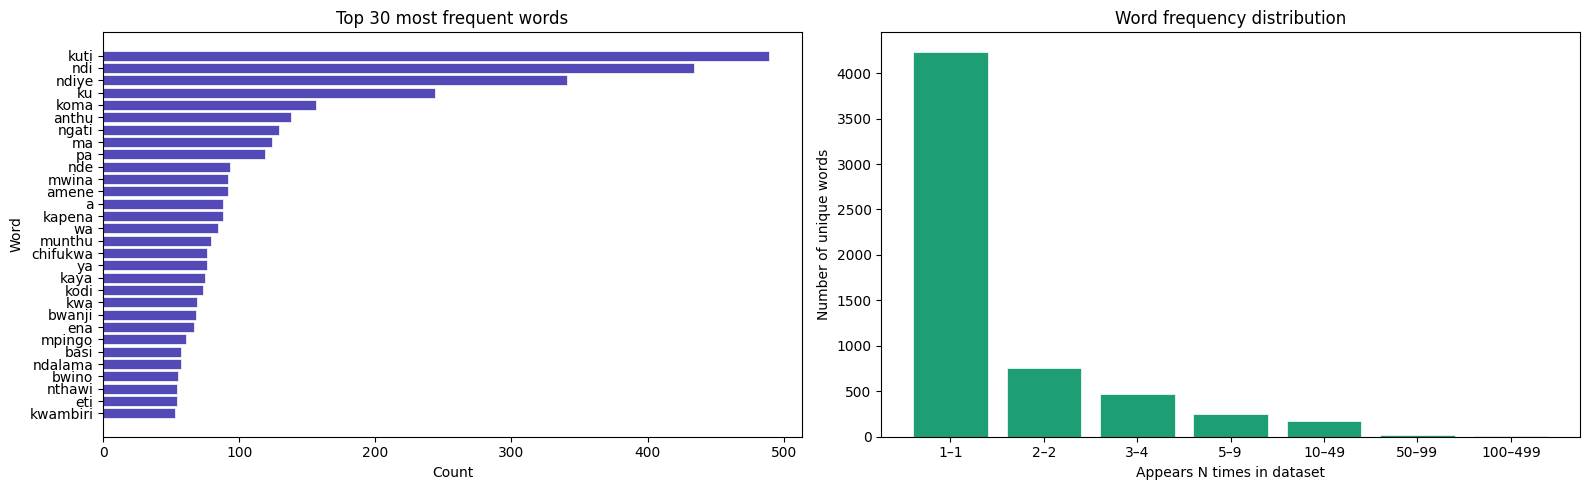

Words appearing only once : 4237 (71.5%)
Words appearing 5+ times  : 456
Words appearing 10+ times : 201


In [22]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

all_words  = " ".join(df["transcript"].tolist()).lower().split()
word_count = Counter(all_words)

# Top 30 words
top_words   = [w for w, c in word_count.most_common(30)]
top_counts  = [c for w, c in word_count.most_common(30)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — top 30 words
axes[0].barh(top_words[::-1], top_counts[::-1], color="#534AB7", edgecolor="white", linewidth=0.5)
axes[0].set_title("Top 30 most frequent words")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Word")

# Frequency distribution — how many words appear once, twice etc.
freq_of_freq = Counter(word_count.values())
buckets      = [1, 2, 3, 5, 10, 50, 100, 500]
labels, vals = [], []
for i in range(len(buckets) - 1):
    lo, hi  = buckets[i], buckets[i+1]
    count   = sum(v for k, v in freq_of_freq.items() if lo <= k < hi)
    labels.append(f"{lo}–{hi-1}")
    vals.append(count)

axes[1].bar(labels, vals, color="#1D9E75", edgecolor="white", linewidth=0.5)
axes[1].set_title("Word frequency distribution")
axes[1].set_xlabel("Appears N times in dataset")
axes[1].set_ylabel("Number of unique words")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/chichewa-asr/word_frequency.png", dpi=150)
plt.show()

# Vocabulary coverage stats
once  = sum(1 for c in word_count.values() if c == 1)
print(f"Words appearing only once : {once} ({once/len(word_count)*100:.1f}%)")
print(f"Words appearing 5+ times  : {sum(1 for c in word_count.values() if c >= 5)}")
print(f"Words appearing 10+ times : {sum(1 for c in word_count.values() if c >= 10)}")

Top 30 words, all genuine high-frequency Chichewa words like kuti (that/where), ndi (is/and), ndiye (so/then), ku (to/at). This confirms your transcripts are authentic Chichewa speech.
Word frequency distribution, this is the critical finding. A massive 4,237 words (71.5%) appear only once in the entire dataset. This is a classic low-resource language problem and means:

Your model will struggle to learn rare words reliably
Only 456 words appear 5+ times, that's the vocabulary your model can realistically learn
You should mention this in your thesis as a key limitation and motivation for using a character-based CTC model rather than a word-based one — character models handle unseen words much better

 **duplicate transcript check**

In [23]:
import pandas as pd
from collections import Counter

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

# Check for exact duplicate transcripts
transcript_counts = Counter(df["transcript"].tolist())
duplicates = {t: c for t, c in transcript_counts.items() if c > 1}

print(f"Total transcripts      : {len(df)}")
print(f"Unique transcripts     : {len(transcript_counts)}")
print(f"Duplicate transcripts  : {len(duplicates)}")

if duplicates:
    print(f"\nDuplicated texts (showing top 10):")
    for text, count in sorted(duplicates.items(), key=lambda x: -x[1])[:10]:
        print(f"\n  Count : {count}")
        print(f"  Text  : {text[:80]}")

    # Show which files share the same transcript
    print(f"\nFiles sharing duplicate transcripts:")
    for text, count in sorted(duplicates.items(), key=lambda x: -x[1])[:5]:
        matches = df[df["transcript"] == text]["audio_path"].tolist()
        print(f"\n  Text: {text[:60]}")
        for m in matches:
            print(f"    {os.path.basename(m)}")

Total transcripts      : 1028
Unique transcripts     : 1027
Duplicate transcripts  : 1

Duplicated texts (showing top 10):

  Count : 2
  Text  : koma ndiye kwamveka fungo loopsya

Files sharing duplicate transcripts:

  Text: koma ndiye kwamveka fungo loopsya
    priscilla_self_records199.wav
    priscilla_self_records402.wav


Only 1 duplicate found, two files from Priscilla share the exact same transcript "koma ndiye kwamveka fungo loopsya". This is easy to fix, we just keep one and remove the other.

**remove the duplicate**

In [24]:
import pandas as pd
import os

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

# Keep first occurrence, drop the second duplicate
df_clean = df.drop_duplicates(subset=["transcript"], keep="first")

print(f"Before : {len(df)} rows")
print(f"After  : {len(df_clean)} rows")
print(f"Dropped: {len(df) - len(df_clean)} duplicate")

# Save
df_clean.to_csv(manifest_path, index=False)
print("Manifest saved!")

Before : 1028 rows
After  : 1027 rows
Dropped: 1 duplicate
Manifest saved!


Speaker               Files      %
------------------------------------
andrew                   97   9.4%
asante                  254  24.7%
au_speaker               50   4.9%
dunstan                 103  10.0%
nya_speaker              55   5.4%
other                     5   0.5%
priscilla               184  17.9%
social_research         226  22.0%
video_audio               4   0.4%
wau_speaker              47   4.6%
whatsapp_audio            2   0.2%


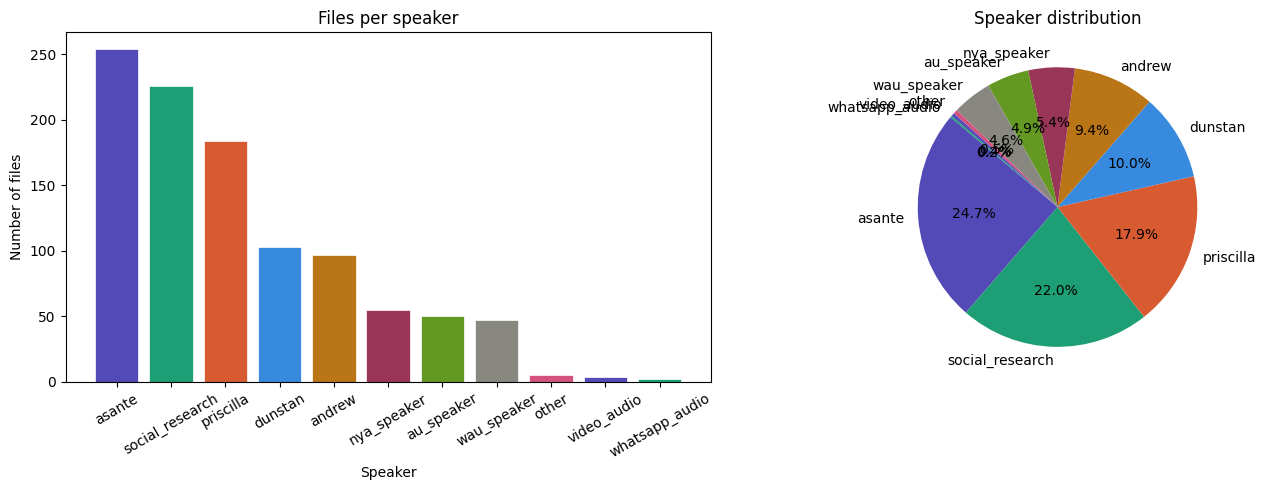

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

def get_speaker(filepath):
    name = os.path.basename(filepath)
    if name.startswith("220"):           return "nya_speaker"
    if name.startswith("andrew"):        return "andrew"
    if name.startswith("asante"):        return "asante"
    if name.startswith("dunstan"):       return "dunstan"
    if name.startswith("priscilla"):     return "priscilla"
    if name.startswith("WAU"):           return "wau_speaker"
    if name.startswith("AU"):            return "au_speaker"
    if name.startswith("transcribed"):   return "social_research"
    if name.startswith("audio_from"):    return "whatsapp_audio"
    if name.startswith("aud_from"):      return "video_audio"
    if name.startswith("dunstan"):       return "dunstan"
    return "other"

df["speaker"] = df["audio_path"].apply(get_speaker)

# Per speaker stats
print(f"{'Speaker':<20} {'Files':>6} {'%':>6}")
print("-" * 36)
for speaker, group in df.groupby("speaker"):
    pct = len(group) / len(df) * 100
    print(f"{speaker:<20} {len(group):>6} {pct:>5.1f}%")

# Plot
speaker_counts = df["speaker"].value_counts()
colors = ["#534AB7","#1D9E75","#D85A30","#378ADD","#BA7517","#993556","#639922","#888780","#D4537E"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(speaker_counts.index, speaker_counts.values,
            color=colors[:len(speaker_counts)], edgecolor="white", linewidth=0.5)
axes[0].set_title("Files per speaker")
axes[0].set_xlabel("Speaker")
axes[0].set_ylabel("Number of files")
axes[0].tick_params(axis="x", rotation=30)

# Pie chart
axes[1].pie(speaker_counts.values, labels=speaker_counts.index,
            colors=colors[:len(speaker_counts)],
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Speaker distribution")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/chichewa-asr/speaker_distribution.png", dpi=150)
plt.show()

We have 11 distinct speaker groups covering a good variety of recording conditions (studio recordings, WhatsApp audio, video audio, social research interviews). The top 4 speakers asante (24.7%), social_research (22.0%), priscilla (17.9%), and dunstan (10.0%) make up 74.6% of the dataset which is reasonable.
The concern, the dataset is somewhat imbalanced. asante alone has 254 files while whatsapp_audio has only 2 and video_audio only 4. This means your model may learn asante's voice better than others. You should mention this in your thesis and ensure your train/test split keeps speaker proportions balanced.

**per-speaker duration and quality**

Speaker               Files   Hours  Avg Dur  Avg RMS
-------------------------------------------------------
andrew                   97    0.53    19.6s   0.2155
asante                  254    0.45     6.3s   0.0381
au_speaker               50    0.07     4.8s   0.0412
dunstan                 103    0.23     8.1s   0.1164
nya_speaker              55    0.13     8.8s   0.1155
other                     5    0.03    20.2s   0.1069
priscilla               184    0.30     6.0s   0.0393
social_research         226    0.94    15.0s   0.0623
video_audio               4    0.02    21.9s   0.0909
wau_speaker              47    0.17    13.1s   0.0791
whatsapp_audio            2    0.01    24.3s   0.1220


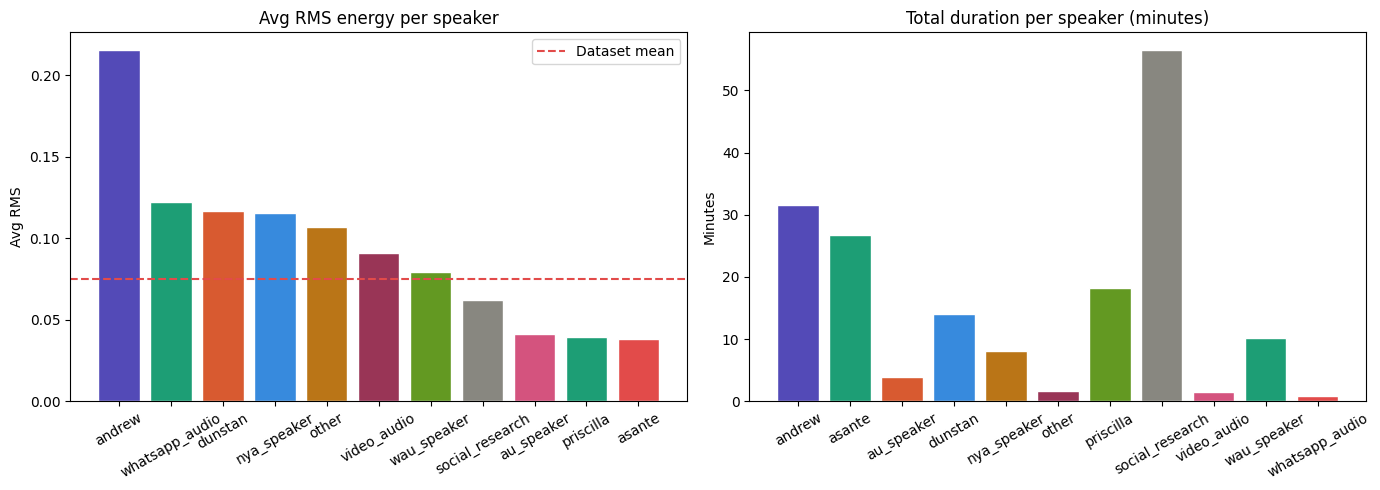

In [26]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt

manifest_path = "/content/drive/MyDrive/chichewa-asr/manifest_clean.csv"
df = pd.read_csv(manifest_path)

# Reattach speaker column
def get_speaker(filepath):
    import os
    name = os.path.basename(filepath)
    if name.startswith("220"):         return "nya_speaker"
    if name.startswith("andrew"):      return "andrew"
    if name.startswith("asante"):      return "asante"
    if name.startswith("dunstan"):     return "dunstan"
    if name.startswith("priscilla"):   return "priscilla"
    if name.startswith("WAU"):         return "wau_speaker"
    if name.startswith("AU"):          return "au_speaker"
    if name.startswith("transcribed"): return "social_research"
    if name.startswith("audio_from"):  return "whatsapp_audio"
    if name.startswith("aud_from"):    return "video_audio"
    return "other"

df["speaker"] = df["audio_path"].apply(get_speaker)

# Compute per-file duration and RMS
durations, rms_vals = [], []
for path in df["audio_path"]:
    y, sr = librosa.load(path, sr=16000)
    durations.append(librosa.get_duration(y=y, sr=sr))
    rms_vals.append(np.sqrt(np.mean(y ** 2)))

df["duration"] = durations
df["rms"]      = rms_vals

# Per-speaker summary
print(f"{'Speaker':<20} {'Files':>6} {'Hours':>7} {'Avg Dur':>8} {'Avg RMS':>8}")
print("-" * 55)
for speaker, g in df.groupby("speaker"):
    hours   = g["duration"].sum() / 3600
    avg_dur = g["duration"].mean()
    avg_rms = g["rms"].mean()
    print(f"{speaker:<20} {len(g):>6} {hours:>7.2f} {avg_dur:>7.1f}s {avg_rms:>8.4f}")

# Plot avg RMS per speaker
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
speaker_rms = df.groupby("speaker")["rms"].mean().sort_values(ascending=False)
speaker_dur = df.groupby("speaker")["duration"].sum() / 60  # minutes

colors = ["#534AB7","#1D9E75","#D85A30","#378ADD","#BA7517","#993556","#639922","#888780","#D4537E","#1D9E75","#E24B4A"]

axes[0].bar(speaker_rms.index, speaker_rms.values,
            color=colors[:len(speaker_rms)], edgecolor="white")
axes[0].set_title("Avg RMS energy per speaker")
axes[0].set_ylabel("Avg RMS")
axes[0].tick_params(axis="x", rotation=30)
axes[0].axhline(df["rms"].mean(), color="#E24B4A", linestyle="--", label="Dataset mean")
axes[0].legend()

axes[1].bar(speaker_dur.index, speaker_dur.values,
            color=colors[:len(speaker_dur)], edgecolor="white")
axes[1].set_title("Total duration per speaker (minutes)")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/chichewa-asr/speaker_quality.png", dpi=150)
plt.show()

Audio quality (RMS), andrew is by far the loudest (0.2155) suggesting close microphone recording, while asante and priscilla are the quietest (0.038) likely recorded on phone at a distance. This volume inconsistency across speakers is normal in real-world datasets and exactly why we did RMS normalization earlier.
Duration per speaker, social_research contributes the most speech time at 0.94 hours (56 minutes) despite not having the most files, because each file is exactly 15 seconds. andrew contributes 0.53 hours with only 97 files because his utterances average 19.6 seconds, the longest of any speaker.
Key thesis insight, your dataset is multi-speaker but unbalanced. For your thesis, recommend that future work collects more data from underrepresented speakers like whatsapp_audio (2 files) and video_audio (4 files).